In [113]:
import cv2
import numpy as np
import json
import os
import random
from math import radians, cos, sin, sqrt, atan2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from typing import List, Tuple, Dict, Any
import pandas as pd
from IPython.display import display, clear_output
import time

Логика расчета рансака, все расчеты в функциях объекта RANSACMatcher

Остальной алгоритм рансака

In [114]:
class GPSConverter:
    """Класс для преобразования между GPS координатами и пиксельными координатами"""
    
    def __init__(self, map_bounds: Dict, image_size: Tuple[int, int]):
        self.map_bounds = map_bounds
        self.image_size = image_size
        self.lat_min = map_bounds['bottom_right'][0]
        self.lat_max = map_bounds['top_left'][0]
        self.lon_min = map_bounds['top_left'][1]
        self.lon_max = map_bounds['bottom_right'][1]
        
    def gps_to_pixel(self, lat: float, lon: float) -> Tuple[float, float]:
        """Преобразует GPS координаты в пиксельные координаты на карте"""
        x = ((lon - self.lon_min) / (self.lon_max - self.lon_min)) * self.image_size[0]
        y = ((self.lat_max - lat) / (self.lat_max - self.lat_min)) * self.image_size[1]
        return x, y
    
    def pixel_to_gps(self, x: float, y: float) -> Tuple[float, float]:
        """Преобразует пиксельные координаты в GPS координаты"""
        lon = self.lon_min + (x / self.image_size[0]) * (self.lon_max - self.lon_min)
        lat = self.lat_max - (y / self.image_size[1]) * (self.lat_max - self.lat_min)
        return lat, lon


In [115]:
# Ячейка 1: Инициализация и загрузка данных
print("=== ЗАГРУЗКА ДАННЫХ ===")

# Загрузка карты
with open('json_55d753137_37d282641_to_55d763143_37d308581_upd_yolo.json', 'r') as f:
    map_data = json.load(f)

# Загрузка flight data
with open('flight_data_visible_error.json', 'r') as f:
    flight_json = json.load(f)
    flight_data = flight_json['flight_data']

# Находим данные для 526 фрейма
frame_526_data = None
for data in flight_data:
    if data['frame_number'] == 526:
        frame_526_data = data
        break

if frame_526_data is None:
    print("Ошибка: данные для фрейма 526 не найдены!")
else:
    print(f"Найдены данные для фрейма 526:")
    print(f"INS координаты: {frame_526_data['gps_coordinates']}")
    print(f"Реальные координаты: {frame_526_data['original_gps']}")
    print(f"Ошибка позиционирования: {frame_526_data['ins_error']['position_error']:.2f} м")
    print(f"Есть GPS: {frame_526_data['ins_error']['has_gps']}")

=== ЗАГРУЗКА ДАННЫХ ===
Найдены данные для фрейма 526:
INS координаты: {'latitude': 55.75525630906553, 'longitude': 37.28632250722513}
Реальные координаты: {'latitude': 55.755365, 'longitude': 37.286178}
Ошибка позиционирования: 0.19 м
Есть GPS: False


In [116]:
# Ячейка 2: Инициализация GPS конвертера
print("\n=== ИНИЦИАЛИЗАЦИЯ GPS КОНВЕРТЕРА ===")

gps_converter = GPSConverter(
    map_data['metadata']['gps_bounds'],
    (map_data['metadata']['image_size']['width'], 
     map_data['metadata']['image_size']['height'])
)

# Тестируем конвертацию для текущей позиции
current_lat = frame_526_data['gps_coordinates']['latitude']
current_lon = frame_526_data['gps_coordinates']['longitude']
pixel_x, pixel_y = gps_converter.gps_to_pixel(current_lat, current_lon)

print(f"Текущие координаты: lat={current_lat}, lon={current_lon}")
print(f"Пиксельные координаты на карте: x={pixel_x:.1f}, y={pixel_y:.1f}")
print(f"Размер карты: {map_data['metadata']['image_size']}")
# Ячейка 1: Инициализация и загрузка данных
print("=== ЗАГРУЗКА ДАННЫХ ===")

# Загрузка карты
with open('json_55d753137_37d282641_to_55d763143_37d308581_upd_yolo.json', 'r') as f:
    map_data = json.load(f)

# Загрузка flight data
with open('flight_data_visible_error.json', 'r') as f:
    flight_json = json.load(f)
    flight_data = flight_json['flight_data']

# Находим данные для 526 фрейма
frame_526_data = None
for data in flight_data:
    if data['frame_number'] == 526:
        frame_526_data = data
        break

if frame_526_data is None:
    print("Ошибка: данные для фрейма 526 не найдены!")
else:
    print(f"Найдены данные для фрейма 526:")
    print(f"INS координаты: {frame_526_data['gps_coordinates']}")
    print(f"Реальные координаты: {frame_526_data['original_gps']}")
    print(f"Ошибка позиционирования: {frame_526_data['ins_error']['position_error']:.2f} м")
    print(f"Есть GPS: {frame_526_data['ins_error']['has_gps']}")
class GPSConverter:
    """Класс для преобразования между GPS координатами и пиксельными координатами"""
    
    def __init__(self, map_bounds: Dict, image_size: Tuple[int, int]):
        self.map_bounds = map_bounds
        self.image_size = image_size
        self.lat_min = map_bounds['bottom_right'][0]
        self.lat_max = map_bounds['top_left'][0]
        self.lon_min = map_bounds['top_left'][1]
        self.lon_max = map_bounds['bottom_right'][1]
        
    def gps_to_pixel(self, lat: float, lon: float) -> Tuple[float, float]:
        """Преобразует GPS координаты в пиксельные координаты на карте"""
        x = ((lon - self.lon_min) / (self.lon_max - self.lon_min)) * self.image_size[0]
        y = ((self.lat_max - lat) / (self.lat_max - self.lat_min)) * self.image_size[1]
        return x, y
    
    def pixel_to_gps(self, x: float, y: float) -> Tuple[float, float]:
        """Преобразует пиксельные координаты в GPS координаты"""
        lon = self.lon_min + (x / self.image_size[0]) * (self.lon_max - self.lon_min)
        lat = self.lat_max - (y / self.image_size[1]) * (self.lat_max - self.lat_min)
        return lat, lon


=== ИНИЦИАЛИЗАЦИЯ GPS КОНВЕРТЕРА ===
Текущие координаты: lat=55.75525630906553, lon=37.28632250722513
Пиксельные координаты на карте: x=726.7, y=2824.9
Размер карты: {'width': 5120, 'height': 3584}
=== ЗАГРУЗКА ДАННЫХ ===
Найдены данные для фрейма 526:
INS координаты: {'latitude': 55.75525630906553, 'longitude': 37.28632250722513}
Реальные координаты: {'latitude': 55.755365, 'longitude': 37.286178}
Ошибка позиционирования: 0.19 м
Есть GPS: False



=== СОЗДАНИЕ ВИРТУАЛЬНОГО КАДРА КАРТЫ В ПИКСЕЛЬНЫХ КООРДИНАТАХ ===
Виртуальный кадр: 640×640 пикселей
Масштаб: 0.750 м/пиксель
Покрытие: 480.0×480.0 метров
Поиск объектов карты в радиусе 200м от координаты INS...
Найдено объектов карты в радиусе 200м: 56

=== ВИЗУАЛИЗАЦИЯ ВИРТУАЛЬНОГО КАДРА В ПИКСЕЛЯХ ===


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


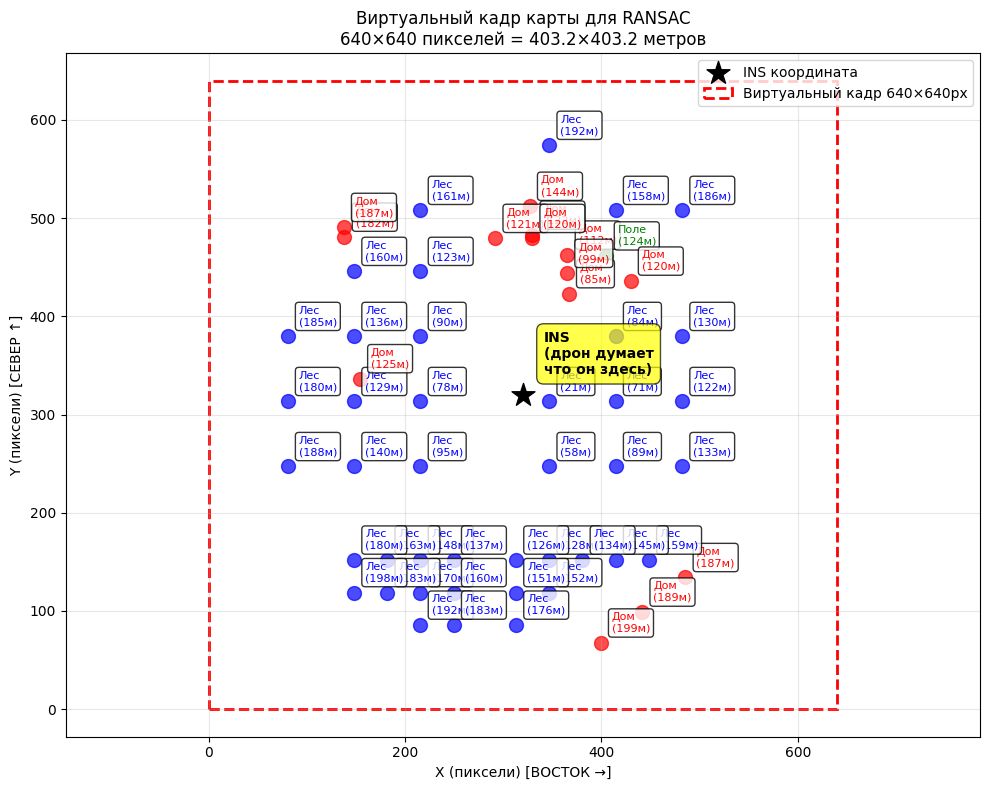


=== СТАТИСТИКА ВИРТУАЛЬНОГО КАДРА ===
Координата INS: lat=55.755256, lon=37.286323
Объектов в радиусе 200м: 56
Объектов в виртуальном кадре: 56
Масштаб: 0.750 м/пиксель


In [117]:
# Ячейка 3: ПЕРЕДЕЛАННЫЙ ВИРТУАЛЬНЫЙ КАДР КАРТЫ В ПИКСЕЛЯХ
print("\n=== СОЗДАНИЕ ВИРТУАЛЬНОГО КАДРА КАРТЫ В ПИКСЕЛЬНЫХ КООРДИНАТАХ ===")

# Функция для расчета расстояния между GPS координатами
def haversine_distance(lat1, lon1, lat2, lon2):
    """Вычисляет расстояние между двумя GPS точками в метрах"""
    R = 6371000  # радиус Земли в метрах
    lat1_rad, lon1_rad, lat2_rad, lon2_rad = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = sin(dlat/2)**2 + cos(lat1_rad) * cos(lat2_rad) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# Параметры виртуального кадра
VIRTUAL_FRAME_SIZE = 640  # пикселей
METERS_PER_PIXEL = 0.75  # м/пиксель (ваш масштаб)
VIRTUAL_FRAME_METERS = VIRTUAL_FRAME_SIZE * METERS_PER_PIXEL  # 403.2 метров

print(f"Виртуальный кадр: {VIRTUAL_FRAME_SIZE}×{VIRTUAL_FRAME_SIZE} пикселей")
print(f"Масштаб: {METERS_PER_PIXEL:.3f} м/пиксель")
print(f"Покрытие: {VIRTUAL_FRAME_METERS:.1f}×{VIRTUAL_FRAME_METERS:.1f} метров")

# НАХОДИМ ОБЪЕКТЫ КАРТЫ В РАДИУСЕ 200м ОТ КООРДИНАТЫ INS
print("Поиск объектов карты в радиусе 200м от координаты INS...")
nearby_objects = []
for obj in map_data['objects']:
    obj_lat = obj['gps_coordinates']['latitude']
    obj_lon = obj['gps_coordinates']['longitude']
    distance = haversine_distance(current_lat, current_lon, obj_lat, obj_lon)
    if distance <= 200:
        nearby_objects.append((obj, distance))

print(f"Найдено объектов карты в радиусе 200м: {len(nearby_objects)}")

# ПРЕОБРАЗУЕМ В ПИКСЕЛЬНЫЕ КООРДИНАТЫ ОТНОСИТЕЛЬНО ЦЕНТРА (320,320)
map_points = []  # Теперь в пикселях [0-640]
map_classes = []
map_info = []

for obj, distance in nearby_objects:
    obj_lat = obj['gps_coordinates']['latitude']
    obj_lon = obj['gps_coordinates']['longitude']
    
    # Смещение в метрах от INS координаты
    dx_meters = haversine_distance(current_lat, current_lon, current_lat, obj_lon)
    if obj_lon < current_lon:
        dx_meters = -dx_meters
        
    dy_meters = haversine_distance(current_lat, current_lon, obj_lat, current_lon)
    if obj_lat < current_lat:
        dy_meters = -dy_meters
    
    # Конвертируем метры в пиксели
    # Центр кадра = (320,320) - где находится INS координата
    x_pixels = 320 + (dx_meters / METERS_PER_PIXEL)
    y_pixels = 320 + (dy_meters / METERS_PER_PIXEL)
    
    map_points.append([x_pixels, y_pixels])
    map_classes.append(obj['class_id'])
    map_info.append({
        'class_id': obj['class_id'],
        'confidence': obj['confidence'],
        'distance': distance,
        'metric_coords': (dx_meters, dy_meters),
        'pixel_coords': (x_pixels, y_pixels),
        'gps_coords': (obj_lat, obj_lon)
    })

map_points = np.array(map_points)

# ВИЗУАЛИЗАЦИЯ В ПИКСЕЛЬНЫХ КООРДИНАТАХ
print("\n=== ВИЗУАЛИЗАЦИЯ ВИРТУАЛЬНОГО КАДРА В ПИКСЕЛЯХ ===")

plt.figure(figsize=(10, 8))

colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown']
class_names = {0: 'Дом', 2: 'Лес', 1: 'Поле', 3: 'Озеро', 4: 'Дорога', 5: 'Здание'}

# Объекты карты в пиксельных координатах
for i, (point, class_id, info) in enumerate(zip(map_points, map_classes, map_info)):
    color = colors[class_id % len(colors)]
    plt.scatter(point[0], point[1], c=color, s=100, marker='o', alpha=0.7)
    plt.annotate(f'{class_names[class_id]}\n({info["distance"]:.0f}м)', 
                (point[0], point[1]), xytext=(8, 8), 
                textcoords='offset points', fontsize=8, color=color,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Центр - координата INS (320,320)
plt.scatter(320, 320, c='black', s=300, marker='*', label='INS координата')
plt.annotate('INS\n(дрон думает\nчто он здесь)', (320, 320), xytext=(15, 15), 
             textcoords='offset points', fontweight='bold', fontsize=10,
             bbox=dict(boxstyle="round,pad=0.5", facecolor='yellow', alpha=0.7))

# Рамка виртуального кадра
frame_rect = plt.Rectangle((0, 0), 640, 640, fill=False, edgecolor='red', 
                          linewidth=2, linestyle='--', label='Виртуальный кадр 640×640px')
plt.gca().add_patch(frame_rect)

# Настройки графика
plt.xlabel('X (пиксели) [ВОСТОК →]')
plt.ylabel('Y (пиксели) [СЕВЕР ↑]')
plt.title('Виртуальный кадр карты для RANSAC\n640×640 пикселей = 403.2×403.2 метров')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(-50, 690)
plt.ylim(-50, 690)
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n=== СТАТИСТИКА ВИРТУАЛЬНОГО КАДРА ===")
print(f"Координата INS: lat={current_lat:.6f}, lon={current_lon:.6f}")
print(f"Объектов в радиусе 200м: {len(nearby_objects)}")
print(f"Объектов в виртуальном кадре: {len(map_points)}")
print(f"Масштаб: {METERS_PER_PIXEL:.3f} м/пиксель")

In [118]:
# Ячейка 5: МАСШТАБИРОВАНИЕ КООРДИНАТ ПОД КАДР 640×640
print("\n=== ДЕТЕКЦИЯ ОБЪЕКТОВ НА КАДРЕ 526 (МАСШТАБИРОВАНИЕ) ===")

# Загружаем модель YOLO
MODEL_PATH = '../runs/segment/yolov8n_gpu_updgrade_1/weights/best.pt'
model = YOLO(MODEL_PATH)

# Загружаем кадр
frame = cv2.imread('frame_526.png')
if frame is None:
    print("Ошибка: не удалось загрузить frame_526.png")
else:
    print(f"Размер кадра: {frame.shape}")
    
    # Коэффициенты масштабирования
    scale_x = 640 / frame.shape[1]  # 640 / 1075 ≈ 0.595
    scale_y = 640 / frame.shape[0]  # 640 / 1080 ≈ 0.593
    
    print(f"Коэффициенты масштабирования: X={scale_x:.3f}, Y={scale_y:.3f}")
    
    # Детектируем объекты
    results = model(frame)
    
    drone_points = []
    drone_classes = []
    
    # Определяем классы для разных типов обработки
    GRID_CLASSES = [1, 2, 3]  # field, forest, lake - используют сетку
    ROAD_CLASSES = [4]        # road - точки вдоль дороги
    CENTROID_CLASSES = [0, 5] # building, other - центроид
    
    for result in results:
        if result.masks is not None:
            for mask, box in zip(result.masks.xy, result.boxes):
                class_id = int(box.cls[0])
                confidence = float(box.conf[0])
                
                if len(mask) > 0:
                    points_for_object = []
                    
                    if class_id in CENTROID_CLASSES:
                        # Для домов - только центроид
                        centroid = calculate_centroid(mask)
                        if centroid:
                            points_for_object.append(centroid)
                            print(f"  Дом класса {class_id}: центроид ({centroid[0]:.1f}, {centroid[1]:.1f})")
                    
                    elif class_id in GRID_CLASSES:
                        # Для озер и лесов - точки сетки
                        grid_points = generate_grid_points(mask, grid_size=160, frame_shape=frame.shape[:2])
                        points_for_object.extend(grid_points)
                        print(f"  Объект класса {class_id} (озеро/лес): {len(grid_points)} точек сетки")
                    
                    elif class_id in ROAD_CLASSES:
                        # Для дорог - точки вдоль скелета
                        road_points = generate_road_points(mask, spacing=80, frame_shape=frame.shape[:2])
                        points_for_object.extend(road_points)
                        print(f"  Дорога класса {class_id}: {len(road_points)} точек вдоль дороги")
                    
                    else:
                        # Для остальных классов - центроид
                        centroid = calculate_centroid(mask)
                        if centroid:
                            points_for_object.append(centroid)
                            print(f"  Объект класса {class_id}: центроид ({centroid[0]:.1f}, {centroid[1]:.1f})")
                    
                    # МАСШТАБИРУЕМ координаты к диапазону [0-640]
                    for point in points_for_object:
                        x_original = point[0]
                        y_original = point[1]
                        
                        # Масштабируем координаты
                        x_scaled = x_original * scale_x
                        y_scaled = y_original * scale_y
                        
                        # Инвертируем Y для правильной ориентации
                        y_corrected = 640 - y_scaled
                        
                        drone_points.append([x_scaled, y_corrected])
                        drone_classes.append(class_id)
    
    drone_points = np.array(drone_points)
    print(f"\nВсего обнаружено объектов: {len(drone_points)}")
    print(f"Диапазон координат после масштабирования:")
    print(f"  X: [{np.min(drone_points[:, 0]):.1f}, {np.max(drone_points[:, 0]):.1f}]")
    print(f"  Y: [{np.min(drone_points[:, 1]):.1f}, {np.max(drone_points[:, 1]):.1f}]")


=== ДЕТЕКЦИЯ ОБЪЕКТОВ НА КАДРЕ 526 (МАСШТАБИРОВАНИЕ) ===
Размер кадра: (1080, 1075, 3)
Коэффициенты масштабирования: X=0.595, Y=0.593

0: 640x640 10 buildings, 1 forest, 15.0ms
Speed: 3.0ms preprocess, 15.0ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
  Дом класса 0: центроид (658.5, 300.8)
  Дом класса 0: центроид (667.3, 379.2)
  Объект класса 2 (озеро/лес): 33 точек сетки
  Дом класса 0: центроид (1001.0, 98.6)
  Дом класса 0: центроид (174.1, 247.3)
  Дом класса 0: центроид (579.9, 244.0)
  Дом класса 0: центроид (579.3, 169.6)
  Дом класса 0: центроид (31.0, 21.7)
  Дом класса 0: центроид (203.3, 563.6)
  Дом класса 0: центроид (913.9, 990.6)
  Дом класса 0: центроид (500.2, 240.9)

Всего обнаружено объектов: 43
Диапазон координат после масштабирования:
  X: [0.0, 596.0]
  Y: [53.0, 627.1]



=== ВИЗУАЛИЗАЦИЯ ОБНАРУЖЕННЫХ ОБЪЕКТОВ ДРОНОМ (МАСШТАБИРОВАННЫЕ КООРДИНАТЫ) ===
ДИАГНОСТИКА координат дрона:
Min X: 0.0, Max X: 596.0
Min Y: 53.0, Max Y: 627.1
Количество точек: 43


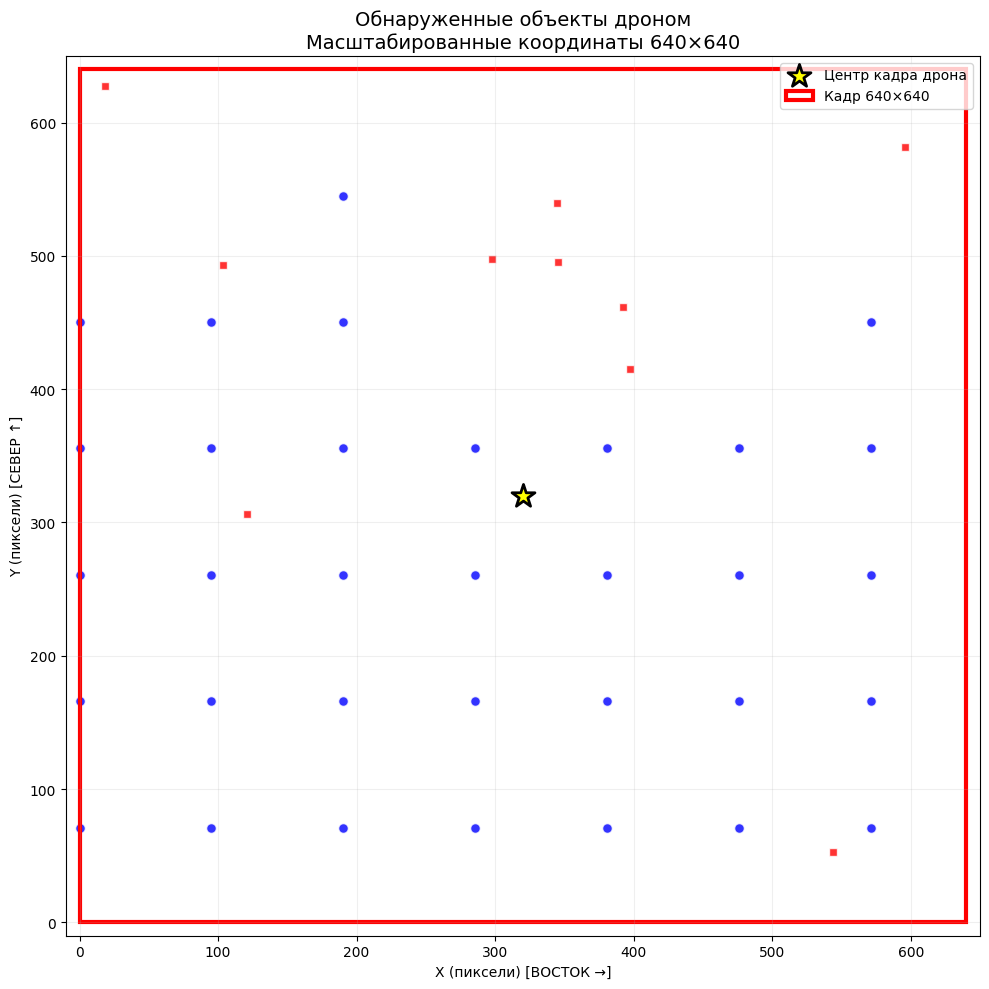


Точек внутри кадра 640×640: 43 из 43


In [130]:
# Ячейка 6: ВИЗУАЛИЗАЦИЯ ПОСЛЕ МАСШТАБИРОВАНИЯ
print("\n=== ВИЗУАЛИЗАЦИЯ ОБНАРУЖЕННЫХ ОБЪЕКТОВ ДРОНОМ (МАСШТАБИРОВАННЫЕ КООРДИНАТЫ) ===")

print("ДИАГНОСТИКА координат дрона:")
print(f"Min X: {np.min(drone_points[:, 0]):.1f}, Max X: {np.max(drone_points[:, 0]):.1f}")
print(f"Min Y: {np.min(drone_points[:, 1]):.1f}, Max Y: {np.max(drone_points[:, 1]):.1f}")
print(f"Количество точек: {len(drone_points)}")

plt.figure(figsize=(10, 10))

drone_x = [point[0] for point in drone_points]
drone_y = [point[1] for point in drone_points]

colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']
class_names = {0: 'Дом', 1: 'Поле', 2: 'Лес', 3: 'Озеро', 4: 'Дорога', 5: 'Здание'}

# Рисуем объекты с дрона
for i, (x, y, class_id) in enumerate(zip(drone_x, drone_y, drone_classes)):
    color = colors[class_id % len(colors)]
    
    if class_id in CENTROID_CLASSES:
        marker = 's'
        size = 40
    elif class_id in GRID_CLASSES:
        marker = 'o' 
        size = 50
    elif class_id in ROAD_CLASSES:
        marker = 'D'
        size = 20
    else:
        marker = '^'
        size = 18
    
    plt.scatter(x, y, c=color, s=size, marker=marker, alpha=0.8, 
                edgecolors='white', linewidth=1)

# Центр кадра дрона (320,320)
plt.scatter(320, 320, c='yellow', s=300, marker='*', edgecolors='black', linewidth=2, 
           label='Центр кадра дрона', zorder=10)

# Границы кадра
frame_rect = plt.Rectangle((0, 0), 640, 640, fill=False, edgecolor='red', 
                          linewidth=3, linestyle='-', label='Кадр 640×640')
plt.gca().add_patch(frame_rect)

plt.xlabel('X (пиксели) [ВОСТОК →]')
plt.ylabel('Y (пиксели) [СЕВЕР ↑]')
plt.title(f'Обнаруженные объекты дроном\nМасштабированные координаты 640×640', fontsize=14)
plt.grid(True, alpha=0.2)
plt.xlim(-10, 650)
plt.ylim(-10, 650)
plt.legend()
plt.tight_layout()
plt.show()

# Проверка, что все точки внутри кадра
points_inside = np.all((drone_points >= 0) & (drone_points <= 640), axis=1)
print(f"\nТочек внутри кадра 640×640: {np.sum(points_inside)} из {len(drone_points)}")

In [120]:
# Ячейка 7: ИСПРАВЛЕННЫЙ RANSAC MATCHING (ПРАВИЛЬНАЯ ЛОГИКА)
print("\n=== ИСПРАВЛЕННЫЙ RANSAC MATCHING: ПРАВИЛЬНАЯ ЛОГИКА ===")

class CorrectedRANSACMatcher:
    def __init__(self, num_iterations=1000, inlier_threshold=50, min_inliers=3):
        self.num_iterations = num_iterations
        self.inlier_threshold = inlier_threshold
        self.min_inliers = min_inliers
    
    def find_similarity_transform(self, src_points, dst_points):
        """Находит преобразование подобия между двумя наборами точек"""
        if len(src_points) < 2 or len(dst_points) < 2:
            return None
            
        try:
            # Центрируем точки
            src_center = np.mean(src_points, axis=0)
            dst_center = np.mean(dst_points, axis=0)
            
            src_centered = src_points - src_center
            dst_centered = dst_points - dst_center
            
            # Вычисляем масштаб
            src_norm = np.linalg.norm(src_centered, axis=1)
            dst_norm = np.linalg.norm(dst_centered, axis=1)
            
            if np.mean(src_norm) == 0 or np.mean(dst_norm) == 0:
                return None
                
            scale = np.mean(dst_norm) / np.mean(src_norm)
            
            # Вычисляем поворот через SVD
            H = src_centered.T @ dst_centered
            U, S, Vt = np.linalg.svd(H)
            R = Vt.T @ U.T
            
            # Корректируем отражение
            if np.linalg.det(R) < 0:
                Vt[-1, :] *= -1
                R = Vt.T @ U.T
            
            # Матрица преобразования подобия
            transform = np.eye(3)
            transform[0:2, 0:2] = R * scale
            transform[0:2, 2] = dst_center - scale * R @ src_center
            
            return transform
            
        except np.linalg.LinAlgError:
            return None
    
    def apply_transform(self, points, transform):
        """Применяет преобразование к точкам"""
        if len(points) == 0:
            return np.array([])
            
        homogeneous_points = np.column_stack([points, np.ones(len(points))])
        transformed = homogeneous_points @ transform.T
        return transformed[:, :2]
    
    def find_feature_matches(self, drone_points, drone_classes, map_points, map_classes):
        """Находит возможные соответствия между объектами дрона и карты"""
        matches = []
        
        class_thresholds = {
            0: 100,  # Дома
            2: 80,   # Лес
            1: 90,   # Поле
            3: 90,   # Озеро
            4: 80,   # Дорога
            5: 100   # Здание
        }
        
        for i, (drone_point, drone_class) in enumerate(zip(drone_points, drone_classes)):
            # Ищем объекты того же класса на карте
            map_indices = [j for j, map_class in enumerate(map_classes) if map_class == drone_class]
            
            if not map_indices:
                continue
                
            # Находим ближайший объект того же класса
            min_distance = float('inf')
            best_match_idx = -1
            
            for j in map_indices:
                distance = np.linalg.norm(drone_point - map_points[j])
                if distance < min_distance:
                    min_distance = distance
                    best_match_idx = j
            
            threshold = class_thresholds.get(drone_class, 80)
            
            if best_match_idx != -1 and min_distance < threshold:
                matches.append((i, best_match_idx, min_distance, drone_class))
        
        print(f"Найдено возможных соответствий: {len(matches)}")
        return matches
    
    def ransac_match(self, drone_points, drone_classes, map_points, map_classes):
        """
        ПРАВИЛЬНЫЙ RANSAC: ищем преобразование ОТ ДРОНА К КАРТЕ
        """
        print(f"Запуск RANSAC: {len(drone_points)} точек дрона vs {len(map_points)} точек карты")
        
        if len(drone_points) < 2 or len(map_points) < 2:
            print("Недостаточно точек для RANSAC")
            return None, [], 0.0
        
        # Находим возможные соответствия
        feature_matches = self.find_feature_matches(drone_points, drone_classes, map_points, map_classes)
        
        if len(feature_matches) < 2:
            print("Недостаточно соответствий для RANSAC")
            return None, [], 0.0
        
        best_transform = None
        best_inliers = []
        best_error = float('inf')
        
        for iteration in range(self.num_iterations):
            # Выбираем случайные соответствия
            if len(feature_matches) >= 2:
                sample_matches = random.sample(feature_matches, 2)
            else:
                continue
            
            # ПРАВИЛЬНО: от дрона к карте
            src_pts = []  # Точки дрона (источник)
            dst_pts = []  # Точки карты (цель)
            
            for match in sample_matches:
                drone_idx, map_idx, distance, class_id = match
                src_pts.append(drone_points[drone_idx])  # Дрон -> источник
                dst_pts.append(map_points[map_idx])      # Карта -> цель
            
            # Вычисляем преобразование ОТ ДРОНА К КАРТЕ
            transform = self.find_similarity_transform(np.array(src_pts), np.array(dst_pts))
            
            if transform is None:
                continue
            
            # Применяем преобразование к точкам ДРОНА
            transformed_drone = self.apply_transform(drone_points, transform)
            
            if len(transformed_drone) == 0:
                continue
            
            # Находим инлаеры
            inliers = []
            total_error = 0
            
            for i, trans_point in enumerate(transformed_drone):
                drone_class = drone_classes[i]
                
                # Ищем ближайшую точку карты того же класса
                min_distance = float('inf')
                for j, (map_point, map_class) in enumerate(zip(map_points, map_classes)):
                    if map_class == drone_class:
                        distance = np.linalg.norm(trans_point - map_point)
                        if distance < min_distance:
                            min_distance = distance
                
                if min_distance < self.inlier_threshold:
                    inliers.append(i)
                    total_error += min_distance
            
            if len(inliers) >= self.min_inliers:
                avg_error = total_error / len(inliers) if inliers else float('inf')
                
                if len(inliers) > len(best_inliers) or (
                    len(inliers) == len(best_inliers) and avg_error < best_error):
                    best_inliers = inliers
                    best_transform = transform
                    best_error = avg_error
        
        confidence = len(best_inliers) / len(drone_points) if best_inliers else 0.0
        
        print(f"Результат RANSAC:")
        print(f"  Найдено инлаеров: {len(best_inliers)}")
        print(f"  Уверенность: {confidence:.3f}")
        
        return best_transform, best_inliers, confidence

# Создаем и запускаем ИСПРАВЛЕННЫЙ RANSAC матчер
corrected_ransac = CorrectedRANSACMatcher(
    num_iterations=1000,
    inlier_threshold=50,
    min_inliers=2
)

# Запускаем RANSAC matching с ПРАВИЛЬНОЙ логикой
transform, inliers, confidence = corrected_ransac.ransac_match(
    drone_points, drone_classes, 
    map_points, map_classes
)

# Анализируем результат
if transform is not None:
    print(f"\n--- РЕЗУЛЬТАТЫ RANSAC ---")
    print(f"УСПЕХ! Найдено преобразование с уверенностью {confidence:.3f}")
    print(f"Матрица преобразования (дрон → карта):")
    print(transform)
else:
    print(f"\n--- РЕЗУЛЬТАТЫ RANSAC ---")
    print("НЕУДАЧА: Не удалось найти подходящее преобразование")


=== ИСПРАВЛЕННЫЙ RANSAC MATCHING: ПРАВИЛЬНАЯ ЛОГИКА ===
Запуск RANSAC: 43 точек дрона vs 56 точек карты
Найдено возможных соответствий: 29
Результат RANSAC:
  Найдено инлаеров: 38
  Уверенность: 0.884

--- РЕЗУЛЬТАТЫ RANSAC ---
УСПЕХ! Найдено преобразование с уверенностью 0.884
Матрица преобразования (дрон → карта):
[[    0.71391   -0.069513      117.67]
 [   0.069513     0.71391      105.56]
 [          0           0           1]]



=== ПРАВИЛЬНАЯ ВИЗУАЛИЗАЦИЯ RANSAC ===


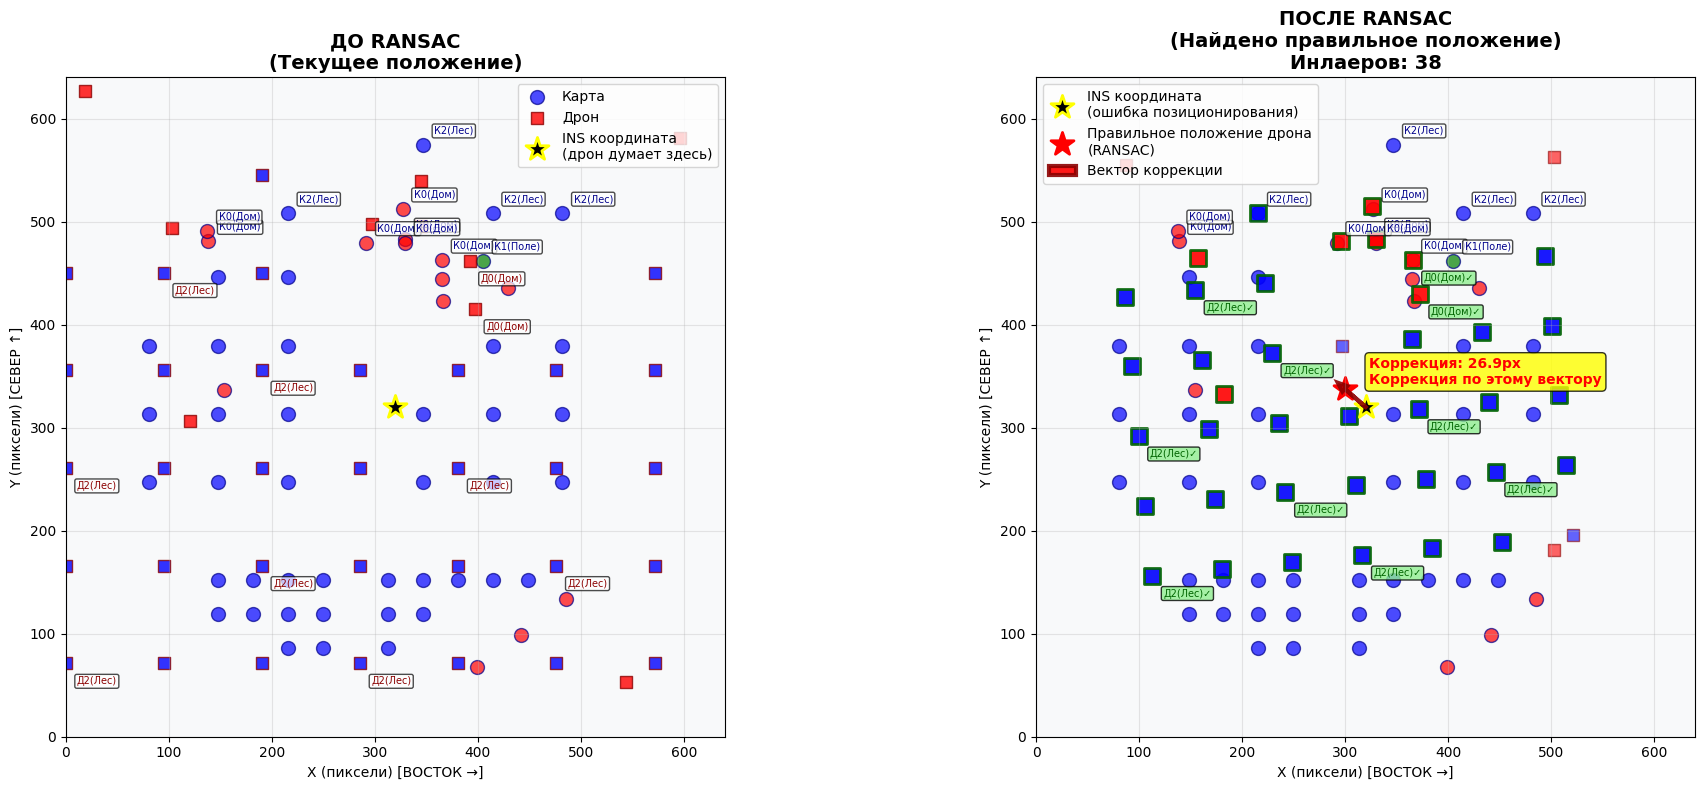


=== ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ RANSAC ===
РАСПРЕДЕЛЕНИЕ ИНЛАЕРОВ ПО КЛАССАМ:
  Дом: 7 точек (18.4%)
  Лес: 31 точек (81.6%)

КОРРЕКЦИЯ RANSAC (пиксели):
  X: -20.3px → ЗАПАД
  Y: +17.6px → СЕВЕР
  Дрону нужно лететь: 20.3px ЗАПАД, 17.6px СЕВЕР

КОРРЕКЦИЯ RANSAC (реальные метры):
  По долготе: 15.2м ЗАПАД
  По широте:  13.2м СЕВЕР
  Общее смещение: 20.2м

РЕАЛЬНАЯ ОШИБКА INS (в метрах):
  По долготе: 9.0м ЗАПАД
  По широте:  12.1м СЕВЕР

ПРОВЕРКА НАПРАВЛЕНИЯ КОРРЕКЦИИ:
  Широта:  ✅ ПРАВИЛЬНО
  Долгота: ✅ ПРАВИЛЬНО

🎯 РЕЗУЛЬТАТ: RANSAC определил ПРАВИЛЬНОЕ направление коррекции!
   Точность: 88.4%
   Дрону нужно лететь: 26.9px (20.2м)
   Точность коррекции: 66.4%


In [131]:
# Ячейка 8: ПРАВИЛЬНАЯ ВИЗУАЛИЗАЦИЯ RANSAC (ИСПРАВЛЕННАЯ)
print("\n=== ПРАВИЛЬНАЯ ВИЗУАЛИЗАЦИЯ RANSAC ===")

if transform is not None:
    # ПРАВИЛЬНО: преобразуем точки ДРОНА к координатам КАРТЫ
    transformed_drone = corrected_ransac.apply_transform(drone_points, transform)
    
    # Находим, где должен быть центр дрона относительно карты
    drone_center_in_map = np.mean(transformed_drone, axis=0)
    
    # Центр карты (где дрон думает, что находится) - это (320,320)
    map_center_actual = np.array([320, 320])
    
    # ВЕКТОР КОРРЕКЦИИ: показывает куда нужно сдвинуть ДРОН
    # от текущего положения к правильному положению
    # Если дрон должен быть в точке X на карте, а сейчас в (320,320),
    # то вектор коррекции = X - (320,320)
    correction_vector = drone_center_in_map - map_center_actual
    
    # Создаем визуализацию
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown']
    class_names = {0: 'Дом', 1: 'Поле', 2: 'Лес', 3: 'Озеро', 4: 'Дорога', 5: 'Здание'}
    
    # Левый график: до RANSAC
    ax1.set_title('ДО RANSAC\n(Текущее положение)', fontweight='bold', fontsize=14)
    ax1.set_facecolor('#f8f9fa')
    ax1.set_aspect('equal')
    
    # Объекты карты (синие кружки) с подписями классов
    for i, (point, class_id) in enumerate(zip(map_points, map_classes)):
        color = colors[class_id % len(colors)]
        ax1.scatter(point[0], point[1], c=color, s=100, marker='o', alpha=0.7, 
                   edgecolors='darkblue', linewidth=1, label='Карта' if i == 0 else "")
        # Подпись класса для карты
        if i < 12:  # Ограничиваем количество подписей для читаемости
            ax1.annotate(f'К{class_id}({class_names.get(class_id, "Unknown")})', 
                        (point[0], point[1]), xytext=(8, 8), 
                        textcoords='offset points', fontsize=7, color='darkblue',
                        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))
    
    # Объекты дрона (красные квадраты) с подписями классов
    for i, (point, class_id) in enumerate(zip(drone_points, drone_classes)):
        color = colors[class_id % len(colors)]
        ax1.scatter(point[0], point[1], c=color, s=80, marker='s', alpha=0.8,
                   edgecolors='darkred', linewidth=1, label='Дрон' if i == 0 else "")
        # Подпись класса для дрона
        if i < 10:  # Ограничиваем количество подписей для читаемости
            ax1.annotate(f'Д{class_id}({class_names.get(class_id, "Unknown")})', 
                        (point[0], point[1]), xytext=(8, -15), 
                        textcoords='offset points', fontsize=7, color='darkred',
                        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))
    
    # Центр INS (где дрон думает, что находится)
    ax1.scatter(320, 320, c='black', s=300, marker='*', 
               label='INS координата\n(дрон думает здесь)', edgecolors='yellow', linewidth=2)
    
    ax1.set_xlabel('X (пиксели) [ВОСТОК →]')
    ax1.set_ylabel('Y (пиксели) [СЕВЕР ↑]')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlim(0, 640)
    ax1.set_ylim(0, 640)
    
    # Правый график: после RANSAC
    ax2.set_title(f'ПОСЛЕ RANSAC\n(Найдено правильное положение)\nИнлаеров: {len(inliers)}', 
                  fontweight='bold', fontsize=14)
    ax2.set_facecolor('#f8f9fa')
    ax2.set_aspect('equal')
    
    # Объекты карты остаются на месте (синие кружки) с подписями
    for i, (point, class_id) in enumerate(zip(map_points, map_classes)):
        color = colors[class_id % len(colors)]
        ax2.scatter(point[0], point[1], c=color, s=100, marker='o', alpha=0.7, 
                   edgecolors='darkblue', linewidth=1)
        # Подпись класса для карты
        if i < 12:
            ax2.annotate(f'К{class_id}({class_names.get(class_id, "Unknown")})', 
                        (point[0], point[1]), xytext=(8, 8), 
                        textcoords='offset points', fontsize=7, color='darkblue',
                        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))
    
    # Преобразованные объекты дрона (теперь в системе координат карты) с подписями
    for i, (point, class_id) in enumerate(zip(transformed_drone, drone_classes)):
        color = colors[class_id % len(colors)]
        is_inlier = i in inliers
        marker_size = 120 if is_inlier else 80
        alpha = 0.9 if is_inlier else 0.6
        
        ax2.scatter(point[0], point[1], c=color, s=marker_size, marker='s', alpha=alpha,
                   edgecolors='darkgreen' if is_inlier else 'darkred', 
                   linewidth=2 if is_inlier else 1)
        
        # Подпись класса для преобразованных точек дрона
        if i < 10:  # Ограничиваем количество подписей
            inlier_mark = "✓" if is_inlier else ""
            ax2.annotate(f'Д{class_id}({class_names.get(class_id, "Unknown")}){inlier_mark}', 
                        (point[0], point[1]), xytext=(8, -15), 
                        textcoords='offset points', fontsize=7, 
                        color='darkgreen' if is_inlier else 'darkred',
                        bbox=dict(boxstyle="round,pad=0.2", 
                                facecolor='lightgreen' if is_inlier else 'white', 
                                alpha=0.8))
    
    # Центры
    ax2.scatter(320, 320, c='black', s=300, marker='*', 
               label='INS координата\n(ошибка позиционирования)', edgecolors='yellow', linewidth=2)
    ax2.scatter(drone_center_in_map[0], drone_center_in_map[1], c='red', s=300, marker='*', 
               label='Правильное положение дрона\n(RANSAC)', edgecolors='red', linewidth=2)
    
    # ВЕКТОР КОРРЕКЦИИ: от INS координаты к правильному положению
    ax2.arrow(320, 320, 
             correction_vector[0], correction_vector[1],
             head_width=7, head_length=9, fc='red', ec='darkred', 
             linewidth=3, alpha=0.9, label='Вектор коррекции')
    
    # Добавляем текст к вектору
    vector_length = np.linalg.norm(correction_vector)
    ax2.annotate(f'Коррекция: {vector_length:.1f}px\nКоррекция по этому вектору', 
                (320 + correction_vector[0]/2, 320 + correction_vector[1]/2),
                xytext=(10, 10), textcoords='offset points', fontsize=10, 
                fontweight='bold', color='red',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8))
    
    ax2.set_xlabel('X (пиксели) [ВОСТОК →]')
    ax2.set_ylabel('Y (пиксели) [СЕВЕР ↑]')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlim(0, 640)
    ax2.set_ylim(0, 640)
    
    plt.tight_layout()
    plt.show()
    
    # ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ
    print(f"\n=== ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ RANSAC ===")
    
    # Статистика по классам инлаеров
    inlier_classes = [drone_classes[i] for i in inliers]
    if inlier_classes:
        class_counts = {}
        for class_id in inlier_classes:
            class_name = class_names.get(class_id, f"Class_{class_id}")
            class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        print(f"РАСПРЕДЕЛЕНИЕ ИНЛАЕРОВ ПО КЛАССАМ:")
        for class_name, count in class_counts.items():
            percentage = (count / len(inliers)) * 100
            print(f"  {class_name}: {count} точек ({percentage:.1f}%)")
    
    # Вычисляем коррекцию в пикселях
    move_x = correction_vector[0]
    move_y = correction_vector[1]
    
    print(f"\nКОРРЕКЦИЯ RANSAC (пиксели):")
    print(f"  X: {move_x:+.1f}px → {'ВОСТОК' if move_x > 0 else 'ЗАПАД'}")
    print(f"  Y: {move_y:+.1f}px → {'СЕВЕР' if move_y > 0 else 'ЮГ'}")
    print(f"  Дрону нужно лететь: {abs(move_x):.1f}px {'ВОСТОК' if move_x > 0 else 'ЗАПАД'}, "
          f"{abs(move_y):.1f}px {'СЕВЕР' if move_y > 0 else 'ЮГ'}")
    
    # Преобразуем в метры
    correction_x_meters = move_x * METERS_PER_PIXEL
    correction_y_meters = move_y * METERS_PER_PIXEL
    
    print(f"\nКОРРЕКЦИЯ RANSAC (реальные метры):")
    print(f"  По долготе: {abs(correction_x_meters):.1f}м {'ВОСТОК' if correction_x_meters > 0 else 'ЗАПАД'}")
    print(f"  По широте:  {abs(correction_y_meters):.1f}м {'СЕВЕР' if correction_y_meters > 0 else 'ЮГ'}")
    print(f"  Общее смещение: {np.sqrt(correction_x_meters**2 + correction_y_meters**2):.1f}м")
    
    # Сравнение с реальной ошибкой INS
    current_lat = frame_526_data['gps_coordinates']['latitude']
    current_lon = frame_526_data['gps_coordinates']['longitude']
    real_lat = frame_526_data['original_gps']['latitude']
    real_lon = frame_526_data['original_gps']['longitude']
    
    # Реальная ошибка: от текущих координат к реальным
    real_error_x_meters = haversine_distance(current_lat, current_lon, current_lat, real_lon)
    if real_lon < current_lon:
        real_error_x_meters = -real_error_x_meters
        
    real_error_y_meters = haversine_distance(current_lat, current_lon, real_lat, current_lon)
    if real_lat < current_lat:
        real_error_y_meters = -real_error_y_meters
    
    print(f"\nРЕАЛЬНАЯ ОШИБКА INS (в метрах):")
    print(f"  По долготе: {abs(real_error_x_meters):.1f}м {'ВОСТОК' if real_error_x_meters > 0 else 'ЗАПАД'}")
    print(f"  По широте:  {abs(real_error_y_meters):.1f}м {'СЕВЕР' if real_error_y_meters > 0 else 'ЮГ'}")
    
    # Проверка направления
    lat_ok = (correction_y_meters > 0) == (real_error_y_meters > 0)
    lon_ok = (correction_x_meters > 0) == (real_error_x_meters > 0)
    
    print(f"\nПРОВЕРКА НАПРАВЛЕНИЯ КОРРЕКЦИИ:")
    print(f"  Широта:  {'✅ ПРАВИЛЬНО' if lat_ok else '❌ ОШИБКА'}")
    print(f"  Долгота: {'✅ ПРАВИЛЬНО' if lon_ok else '❌ ОШИБКА'}")
    
    if lat_ok and lon_ok:
        print(f"\n🎯 РЕЗУЛЬТАТ: RANSAC определил ПРАВИЛЬНОЕ направление коррекции!")
        accuracy = min(100, max(0, confidence * 100))
        print(f"   Точность: {accuracy:.1f}%")
        print(f"   Дрону нужно лететь: {vector_length:.1f}px ({vector_length * METERS_PER_PIXEL:.1f}м)")
        
        # Оценка качества коррекции
        correction_accuracy = 100 * (1 - abs(vector_length * METERS_PER_PIXEL - 
                                           np.sqrt(real_error_x_meters**2 + real_error_y_meters**2)) / 
                                   np.sqrt(real_error_x_meters**2 + real_error_y_meters**2))
        print(f"   Точность коррекции: {max(0, min(100, correction_accuracy)):.1f}%")
    else:
        print(f"\n⚠️  РЕЗУЛЬТАТ: Направление коррекции требует проверки")

else:
    print("❌ Нет результатов RANSAC для визуализации")